<a href="https://colab.research.google.com/github/gk2311/AIHC5020/blob/main/homework3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import duckdb

## Synthetic Student Data

Here is a simple table of student records.

| StudentID | Name    | Score | Major            |
|-----------|---------|-------|------------------|
| 101       | Alice   | 85    | Computer Science |
| 102       | Bob     | 92    | Physics          |
| 103       | Charlie | 78    | Mathematics      |
| 104       | David   | 95    | Computer Science |
| 105       | Eve     | 88    | Biology          |
| 106       | Frank   | 72    | Mathematics      |
| 107       | Grace   | 99    | Physics          |
| 108       | Heidi   | 81    | Biology          |
| 109       | Ivan    | 90    | Computer Science |
| 110       | Judy    | 84    | Mathematics      |

---

## Problem 1: DataFrame initialization from data structures

Your task is to create a pandas DataFrame that contains the data from the table above. You must demonstrate that you can create the *exact same* DataFrame in three different ways.

**Requirements:**

### 1. Method 1: From a List of Dictionaries
- Create a list where each element is a dictionary.
- Each dictionary should represent one row of the table (e.g., `{'StudentID': 101, 'Name': 'Alice', ...}`).
- Use this list of dictionaries to initialize a pandas DataFrame.

### 2. Method 2: From a Dictionary of Lists
- Create a dictionary where each key is a column name (e.g., `'StudentID'`).
- The value for each key should be a list containing all the values for that column.
- Use this dictionary of lists to initialize a pandas DataFrame.

### 3. Method 3: From a List of Lists
- Create a list where each inner list represents one row of data (e.g., `[101, 'Alice', 85, 'Computer Science']`).
- Use this list of lists to initialize a pandas DataFrame.
- **Important:** When using this method, you will also need to manually provide the column names.

For each method, print the resulting DataFrame to the console to verify it was created correctly.

In [2]:
# Method 1: From a List of Dictionaries
list_of_dicts = [
    {'StudentID': 101, 'Name': 'Alice',   'Score': 85, 'Major': 'Computer Science'},
    {'StudentID': 102, 'Name': 'Bob',     'Score': 92, 'Major': 'Physics'},
    {'StudentID': 103, 'Name': 'Charlie', 'Score': 78, 'Major': 'Mathematics'},
    {'StudentID': 104, 'Name': 'David',   'Score': 95, 'Major': 'Computer Science'},
    {'StudentID': 105, 'Name': 'Eve',     'Score': 88, 'Major': 'Biology'},
    {'StudentID': 106, 'Name': 'Frank',   'Score': 72, 'Major': 'Mathematics'},
    {'StudentID': 107, 'Name': 'Grace',   'Score': 99, 'Major': 'Physics'},
    {'StudentID': 108, 'Name': 'Heidi',   'Score': 81, 'Major': 'Biology'},
    {'StudentID': 109, 'Name': 'Ivan',    'Score': 90, 'Major': 'Computer Science'},
    {'StudentID': 110, 'Name': 'Judy',    'Score': 84, 'Major': 'Mathematics'},
]
df1 = pd.DataFrame(list_of_dicts)

# Method 2: From a Dictionary of Lists
dict_of_lists = {
    'StudentID': [101, 102, 103, 104, 105, 106, 107, 108, 109, 110],
    'Name':      ['Alice', 'Bob', 'Charlie', 'David', 'Eve',
                  'Frank', 'Grace', 'Heidi', 'Ivan', 'Judy'],
    'Score':     [85, 92, 78, 95, 88, 72, 99, 81, 90, 84],
    'Major':     ['Computer Science', 'Physics', 'Mathematics', 'Computer Science',
                  'Biology', 'Mathematics', 'Physics', 'Biology',
                  'Computer Science', 'Mathematics'],
}
df2 = pd.DataFrame(dict_of_lists)

# Method 3: From a List of Lists
list_of_lists = [
    [101, 'Alice',   85, 'Computer Science'],
    [102, 'Bob',     92, 'Physics'],
    [103, 'Charlie', 78, 'Mathematics'],
    [104, 'David',   95, 'Computer Science'],
    [105, 'Eve',     88, 'Biology'],
    [106, 'Frank',   72, 'Mathematics'],
    [107, 'Grace',   99, 'Physics'],
    [108, 'Heidi',   81, 'Biology'],
    [109, 'Ivan',    90, 'Computer Science'],
    [110, 'Judy',    84, 'Mathematics'],
]
columns = ['StudentID', 'Name', 'Score', 'Major']   # providing column names manually
df3 = pd.DataFrame(list_of_lists, columns=columns)

# Validation
print("Method 1: From a List of Dictionaries")
print(df1)
print("\nMethod 2: From a Dictionary of Lists")
print(df2)
print("\nMethod 3: From a List of Lists")
print(df3)

# Sanity Check
print("\ndf1 equals df2:", df1.equals(df2))
print("df1 equals df3:", df1.equals(df3))

Method 1: From a List of Dictionaries
   StudentID     Name  Score             Major
0        101    Alice     85  Computer Science
1        102      Bob     92           Physics
2        103  Charlie     78       Mathematics
3        104    David     95  Computer Science
4        105      Eve     88           Biology
5        106    Frank     72       Mathematics
6        107    Grace     99           Physics
7        108    Heidi     81           Biology
8        109     Ivan     90  Computer Science
9        110     Judy     84       Mathematics

Method 2: From a Dictionary of Lists
   StudentID     Name  Score             Major
0        101    Alice     85  Computer Science
1        102      Bob     92           Physics
2        103  Charlie     78       Mathematics
3        104    David     95  Computer Science
4        105      Eve     88           Biology
5        106    Frank     72       Mathematics
6        107    Grace     99           Physics
7        108    Heidi     81   

## Problem 2: Slicing Data with `.loc`

Now that you have your DataFrame, let's practice selecting specific parts of it using the powerful `.loc` indexer. The `.loc` indexer is primarily **label-based**, which means you use the index labels (in our case, `0` through `9`) and the column names to select data.

The basic syntax is `df.loc[row_label, column_label]`.

**Starting DataFrame:**

Assume you have the student DataFrame created in the previous problem. For this exercise, we will refer to it as `student_df`.

**Tasks:**

Using the `student_df` DataFrame and the `.loc` indexer, complete the following tasks. Print the result of each task to the console.

1. **Select a Single Row:** Select all information for the student at index `3`.
2. **Select a Single Column:** Select the `Score` column for all students.
3. **Select a Single Value (Cell):** Find the `Major` of the student at index `6`.
4. **Select a Range of Rows:** Select the records for students from index `2` to `5`.
5. **Select Multiple Specific Rows and Columns:** Select the `Name` and `Major` for the students at indices `0`, `4`, and `9`.

In [3]:
# student_df from Problem 1
dict_of_lists = {
    'StudentID': [101, 102, 103, 104, 105, 106, 107, 108, 109, 110],
    'Name':      ['Alice', 'Bob', 'Charlie', 'David', 'Eve',
                  'Frank', 'Grace', 'Heidi', 'Ivan', 'Judy'],
    'Score':     [85, 92, 78, 95, 88, 72, 99, 81, 90, 84],
    'Major':     ['Computer Science', 'Physics', 'Mathematics', 'Computer Science',
                  'Biology', 'Mathematics', 'Physics', 'Biology',
                  'Computer Science', 'Mathematics'],
}
student_df = pd.DataFrame(dict_of_lists)

# Task 1: Single Row
print("Task 1: Single Row (index 3)")
print(student_df.loc[3])

# Task 2: Single Column
print("\nTask 2: Single Column (Score)")
print(student_df.loc[:, 'Score'])

# Task 3: Single Value (Cell)
print("\nTask 3: Single Value (Major at index 6)")
print(student_df.loc[6, 'Major'])

# Task 4: Range of Rows
print("\nTask 4: Range of Rows (2 to 5)")
print(student_df.loc[2:5])

# Task 5: Multiple Specific Rows and Columns
print("\nTask 5: Name and Major for indices 0, 4, 9")
print(student_df.loc[[0, 4, 9], ['Name', 'Major']])

Task 1: Single Row (index 3)
StudentID                 104
Name                    David
Score                      95
Major        Computer Science
Name: 3, dtype: object

Task 2: Single Column (Score)
0    85
1    92
2    78
3    95
4    88
5    72
6    99
7    81
8    90
9    84
Name: Score, dtype: int64

Task 3: Single Value (Major at index 6)
Physics

Task 4: Range of Rows (2 to 5)
   StudentID     Name  Score             Major
2        103  Charlie     78       Mathematics
3        104    David     95  Computer Science
4        105      Eve     88           Biology
5        106    Frank     72       Mathematics

Task 5: Name and Major for indices 0, 4, 9
    Name             Major
0  Alice  Computer Science
4    Eve           Biology
9   Judy       Mathematics


## Problem 3: Reindexing for Meaningful Lookups

Currently, our DataFrame uses a default integer index (`0`, `1`, `2`, ...). While useful, it's not very descriptive. If we wanted to look up a student, it would be more intuitive to use their unique `StudentID` instead of their arbitrary row number.

The process of changing the index of a DataFrame is called **reindexing**. We can use the `.set_index()` method to accomplish this.

**Important Note:** By default, methods like `.set_index()` do not modify the original DataFrame. Instead, they return a *new* DataFrame with the changes applied. You must assign this new DataFrame to a variable to save your work.

**Tasks:**

### 1. Reindex the DataFrame:
- Using the original `student_df` from the previous exercises, create a new DataFrame called `df_reindexed`.
- Set the index of this new DataFrame to be the `StudentID` column.
- Print the `df_reindexed` DataFrame to confirm that the index has changed. You should see `StudentID` in bold on the left, where the old `0`, `1`, `2`... index used to be.

### 2. Select Data with the New Index:
- Now, use the `.loc` indexer on your `df_reindexed` DataFrame to select the complete records for the students **Bob, David, and Grace**.
- *Hint:* You will need to use their `StudentID` values in your `.loc` call.
- Print the resulting selection.

In [4]:
# Task 1: Reindex the DataFrame
df_reindexed = student_df.set_index('StudentID')

print("Task 1: DataFrame reindexed by StudentID")
print(df_reindexed)

# Task 2: Select data using the new index (StudentID values)
selection = df_reindexed.loc[[102, 104, 107]]

print("\nTask 2: Records for Bob, David, and Grace")
print(selection)

Task 1: DataFrame reindexed by StudentID
              Name  Score             Major
StudentID                                  
101          Alice     85  Computer Science
102            Bob     92           Physics
103        Charlie     78       Mathematics
104          David     95  Computer Science
105            Eve     88           Biology
106          Frank     72       Mathematics
107          Grace     99           Physics
108          Heidi     81           Biology
109           Ivan     90  Computer Science
110           Judy     84       Mathematics

Task 2: Records for Bob, David, and Grace
            Name  Score             Major
StudentID                                
102          Bob     92           Physics
104        David     95  Computer Science
107        Grace     99           Physics


## Problem 4: Position-Based Slicing with `.iloc`

In the last exercise, you used `.loc` to select data using the new `StudentID` index labels. Now, we'll introduce its counterpart: `.iloc`.

The `.iloc` indexer is strictly **integer-position based**. This means it always uses the numerical position of rows and columns (starting from `0`), completely ignoring the index labels or column names. This is similar to how you would slice a standard Python list.

The basic syntax is `df.iloc[row_position, column_position]`.

**Task:**

Your goal is to select the exact same rows as in the previous problem (the records for **Bob, David, and Grace**) from the `df_reindexed` DataFrame, but this time you **must** use the `.iloc` indexer.

### 1. Identify Positions:
Look at your `df_reindexed` DataFrame. What are the integer *positions* (starting from 0) of the rows for Bob, David, and Grace?

### 2. Select with `.iloc`:
Use these integer positions to select the three rows using `.iloc`.

### 3. Print the Result:
Print your selection to the console. The output should be identical to the output from the last task in Problem 3.

In [5]:
selection = df_reindexed.iloc[[1, 3, 6]]

print("Records for Bob, David, and Grace (via .iloc positions 1, 3, 6):")
print(selection)

Records for Bob, David, and Grace (via .iloc positions 1, 3, 6):
            Name  Score             Major
StudentID                                
102          Bob     92           Physics
104        David     95  Computer Science
107        Grace     99           Physics


## Problem 5: Conditional Selection and Querying

So far, we have selected data based on its *location* (i.e., its index label or integer position). A more powerful technique is to select data based on its *content*. For example, "find all students in a specific major" or "find all students who scored above a certain threshold."

We will explore two common ways to do this.

1. **Boolean Indexing:** You create a "boolean Series" (a list of `True` / `False` values) based on a condition. You then use `.loc` to select only the rows where the value is `True`.
2. **The `.query()` Method:** A more readable and concise method where you write your condition as a string.

**Tasks:**

You will be working with the `df_reindexed` DataFrame from the previous exercises.

### 1. Filter with Boolean Indexing:
- Create a boolean Series that is `True` for every student whose `Major` is 'Mathematics' and `False` otherwise.
- Use this boolean Series with the `.loc` indexer to select all the rows for Mathematics majors.
- Print the resulting DataFrame.

### 2. Filter with the `.query()` Method:
- Use the `.query()` method to select all students whose `Score` is greater than 85.
- Print the resulting DataFrame.


In [6]:
# Task 1: Filter with Boolean Indexing
is_math = df_reindexed['Major'] == 'Mathematics'
print("Boolean Series (True = Mathematics major):")
print(is_math)

math_majors = df_reindexed.loc[is_math]
print("\nTask 1: Mathematics majors (Boolean Indexing)")
print(math_majors)

# Task 2: Filter with the .query() method
high_scorers = df_reindexed.query('Score > 85')
print("\nTask 2: Students with Score > 85 (.query())")
print(high_scorers)

Boolean Series (True = Mathematics major):
StudentID
101    False
102    False
103     True
104    False
105    False
106     True
107    False
108    False
109    False
110     True
Name: Major, dtype: bool

Task 1: Mathematics majors (Boolean Indexing)
              Name  Score        Major
StudentID                             
103        Charlie     78  Mathematics
106          Frank     72  Mathematics
110           Judy     84  Mathematics

Task 2: Students with Score > 85 (.query())
            Name  Score             Major
StudentID                                
102          Bob     92           Physics
104        David     95  Computer Science
105          Eve     88           Biology
107        Grace     99           Physics
109         Ivan     90  Computer Science


## Problem 6: Combining Filtering and Sorting to Find Top Performers

Real-world data analysis often involves combining several steps to answer a specific question. In this exercise, you will create a reusable function that finds the top-performing student within a given major.

This will require you to:

1. Filter the DataFrame to isolate a specific group.
2. Sort that group based on a value.
3. Select the top record from the sorted group.

**Task:**

Write a Python function called `find_top_student_in_major` that takes two arguments:

1. `df`: A pandas DataFrame (you will use the original `student_df`).
2. `major_name`: A string representing the major to search within (e.g., `'Computer Science'`).

The function should perform the following steps:

1. Filter the input DataFrame `df` to get only the rows corresponding to the given `major_name`.
2. Sort this filtered DataFrame by the `Score` column in **descending order** (so the highest score is first).
3. Select the first row of the sorted DataFrame. This row represents the top student.
4. From this top student's record, extract only their `Name` and `Score`.
5. Return the `Name` and `Score` as a pandas Series.

**Note:** Be sure to handle the case where the specified `major_name` is not found in the input DataFrame by printing a useful message to the user, rather than raising an exception.

**Test your function:**

- Call your function with the major `'Computer Science'`.
- Call your function with the major `'Physics'`.
- Call your function with the major `'Chemistry'`.

In [7]:
def find_top_student_in_major(df, major_name):
    # Step 1: Filter to rows matching the given major
    major_df = df[df['Major'] == major_name]

    # handle the case where the major is not found
    if major_df.empty:
        print(f"No students found for the major '{major_name}'.")
        return None

    # Step 2: Sort by Score in DESCENDING order (highest first)
    sorted_df = major_df.sort_values(by='Score', ascending=False)

    # Step 3: Select the first (top) row
    top_student = sorted_df.iloc[0]

    # Steps 4 & 5: Extract only Name and Score, return as a pandas Series
    return top_student[['Name', 'Score']]


# Test Cases
print("Top student in Computer Science:")
print(find_top_student_in_major(student_df, 'Computer Science'))

print("\nTop student in Physics:")
print(find_top_student_in_major(student_df, 'Physics'))

print("\nTop student in Chemistry:")
print(find_top_student_in_major(student_df, 'Chemistry'))

Top student in Computer Science:
Name     David
Score       95
Name: 3, dtype: object

Top student in Physics:
Name     Grace
Score       99
Name: 6, dtype: object

Top student in Chemistry:
No students found for the major 'Chemistry'.
None


# Part 2: Processing tabular data using Pandas

**The remaining questions will be addressed using a realistic toy dataset that has been shared with you via Google Drive.**

## Accessing Files from Google Drive in Colab

Google Colab provides a temporary, cloud-based environment for running your Python code. This means any files you upload directly to the Colab session will be deleted when the session ends. To work with persistent files (like datasets), the best practice is to store them in your Google Drive and "mount" your Drive in your Colab notebook. For this course, we have shared a Google Drive folder with you that contains the data you will need for this and future assignments. If you cannot see the files after following the instructions below, double check that you made a short cut to the shared AIHC 5020 Google Drive folder as described in the lecture video and then contact the instructor.

Mounting your Google Drive connects it to your Colab session, making it act like a local hard drive. Here's how to do it in a few simple steps.

### Step 1: Run the Mount Command

Execute the following code cell in your notebook. This code imports the necessary `drive` library from Google's tools and tells it to mount your Drive at the directory `/content/drive/`.

    # Import the drive library from google.colab
    from google.colab import drive

    # Start the mounting process
    drive.mount('/content/drive')

### Step 2: Authorize Access

When you run the code above, you should see a new browser window requesting permission for your notebook to access Google Drive. Grant requested access to proceed. Depending on your environment, you might instead see output that includes a URL and an input box for an authorization code. In that case:

1. **Click the URL** (it starts with `https://accounts.google.com/o/oauth2/auth...`).
2. A new browser tab will open. **Choose the Google account** associated with the Drive you want to access.
3. You will be asked to grant Google Drive File Stream permission to access your files. Click **"Allow"** or **"Continue"**.
4. A new screen will appear with your **authorization code**. Click the copy button next to the code.
5. Go back to your Colab notebook, **paste the code** into the input box labeled "Enter your authorization code:", and press Enter.

### Step 3: Verify the Mount

After a few seconds, you should see the message: `Mounted at /content/drive`

This confirms that your Google Drive is successfully connected!

You can also verify this visually. Click the **folder icon** (📁) in the left-hand sidebar. You will now see a `drive` folder. If you expand it, you will see a `My Drive` folder, which is the root of your Google Drive. All of your folders and files will be inside it.

### Step 4: Constructing the File Path

Now that your Drive is mounted, you can access any file using its full path. The path will always start with `/content/drive/My Drive/`. Files used in this course will be shared in the shared AIHC5020 folder. If you have created the Google Drive shortcut to this folder correctly, you will be able to find the files in the folder `/content/drive/MyDrive/AIHC5020/` after mounting.

For the rest of this assignment, we will be working with a commonly used toy dataset related to stroke risk factors. Details about this dataset can be found https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset.

The dataset consists of two files. The main data file is in `/content/drive/MyDrive/AIHC5020/stroke/healthcare-dataset-stroke-data.csv` and an auxiliary file with geographic information is in `/content/drive/MyDrive/AIHC5020/stroke/location_codes.csv`. **IMPORTANT NOTE:** The `location_code` column on the main data file and the `location_codes.csv` file are synthetic additions to this dataset made specifically for this course, and will not be found in the original Kaggle dataset linked above.

If everything is mounted successfully, you can now load the data in your notebook using pandas.



## Problem 7: Applying Row-Level Operations to Create New Columns

Often, you need to create a new feature based on a more complex set of rules involving multiple columns in a row. While simple arithmetic (e.g., `df['col_a'] + df['col_b']`) works for basic cases, you need a more powerful tool for custom logic.

This is where the `.apply()` method comes in. It allows you to apply a custom function to each row (or column) of a DataFrame. When used for row-wise operations, you must specify `axis=1`.

### The Task

Your goal is to create a new binary column in the `stroke_df` DataFrame called `cardiovascular_disease`. This feature will consolidate information from two other columns: `hypertension` and `heart_disease`.

**Logic:** The `cardiovascular_disease` column should be `1` if a person has either hypertension (`hypertension` column is `1`) or heart disease (`heart_disease` column is `1`). If the person has neither condition, the value should be `0`.

### Steps to Follow

#### 1. Define a Function

Write a small Python function that takes a single argument, `row`. This function will contain the logic for determining the value of the new column.

Inside the function:

- Access the values of `'hypertension'` and `'heart_disease'` from the row object (e.g., `row['hypertension']`).
- Use an `if` statement to check if either value is `1`.
- Return `1` if the condition is true, and `0` otherwise.

#### 2. Apply the Function

Use the `.apply()` method on `stroke_df` to execute your function on every row. Remember to specify `axis=1`.

#### 3. Create the New Column

Assign the result of the `.apply()` operation to a new column named `'cardiovascular_disease'`.

#### 4. Verify Your Work

Print the first few rows of the DataFrame, showing the `hypertension`, `heart_disease`, and new `cardiovascular_disease` columns to confirm your logic is working correctly.

Also, print the value counts of your new column.
`

In [8]:
# Import the drive library from google.colab
from google.colab import drive

# Start the mounting process
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
stroke_df = pd.read_csv("/content/drive/MyDrive/AIHC5020/stroke/healthcare-dataset-stroke-data.csv")

In [10]:
# Step 1: Define a function that operates on a single row
def has_cardiovascular_disease(row):
    if row['hypertension'] == 1 or row['heart_disease'] == 1:
        return 1
    else:
        return 0

# Step 2 & 3: Apply row-wise (axis=1) and assign to a new column
stroke_df['cardiovascular_disease'] = stroke_df.apply(has_cardiovascular_disease, axis=1)

# Step 4: Verify
print(stroke_df[['hypertension', 'heart_disease', 'cardiovascular_disease']].head())
print()
print(stroke_df['cardiovascular_disease'].value_counts())

   hypertension  heart_disease  cardiovascular_disease
0             0              1                       1
1             0              0                       0
2             0              1                       1
3             0              0                       0
4             1              0                       1

cardiovascular_disease
0    4400
1     710
Name: count, dtype: int64


md_text = r"""
# Problem 8: Exploratory visualizations

A critical skill in data analysis is visualizing the distribution of your data to uncover patterns. A histogram is a fundamental tool for this; showing how frequently values appear within certain ranges. We can gain even more insight by comparing the distributions of a variable across different groups. For example: *Is the age distribution different for people who have had a stroke versus those who have not?*

## Task:

Write a Python function called `plot_histograms_by_category` that generates comparative histograms for each group in a binary or categorical column.

## Function Requirements:

### Arguments: The function must accept three arguments:

i. `df`: The pandas DataFrame to use (e.g., `stroke_df`).

ii. `continuous_col`: A string with the name of a continuous column (e.g., `'age'` or `'bmi'`).

iii. `categorical_col`: A string with the name of a categorical column (e.g., `'stroke'`).

### Functionality:

i. Initialize a figure and axes object using `fig, ax = plt.subplots()`. Feel free to set a `figsize` (e.g., `figsize=(10, 6)`).

ii. Find the unique values in the `categorical_col`.

iii. Loop through each unique category. In each iteration:

&nbsp;&nbsp;&nbsp;&nbsp;a. Filter the DataFrame `df` to get a subset of data for the current category.

&nbsp;&nbsp;&nbsp;&nbsp;b. Plot a histogram for the `continuous_col` of this subset by calling `ax.hist()`.

iv. **Important:** Use the `alpha` parameter in `ax.hist()` to add transparency (e.g., `alpha=0.6`) so the histograms don't obscure each other.

v. Add a `label` to each histogram (e.g., `label=f'Stroke = {category}'`) so you can create a legend.

vi. After the loop, use the appropriate `ax` methods to add a descriptive title, an x-axis label, and a y-axis label to the plot (e.g., `ax.set_title(...)`).

vii. Display a legend using `ax.legend()`.

viii. Display the final plot using `plt.show()`.

### Edge cases:

Be sure to handle these edge cases by printing a useful message and returning `None`.

i. A categorical column is accidentally provided for the `continuous_col` argument, or a continuous column is accidentally provided for the `categorical_col` argument. You can test for this heuristically by counting the unique values found in each column, treating a column as categorical if there are fewer than some small number, say 10.

ii. Either provided column is not found in the dataframe.

## Test your function:

1. Call your function to compare the distribution of `'age'` for each value in the `'stroke'` column (0 for no stroke, 1 for stroke).

2. Call your function again to compare the distribution of `'bmi'` for each value in the `'gender'` column.

3. Call your function again using `'stroke'` for the continuous column and `'age'` for the categorical column.
"""

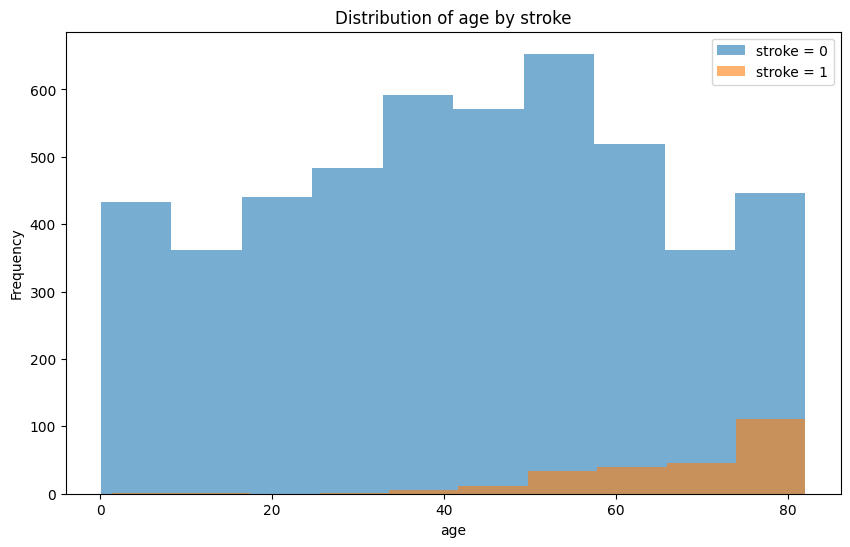

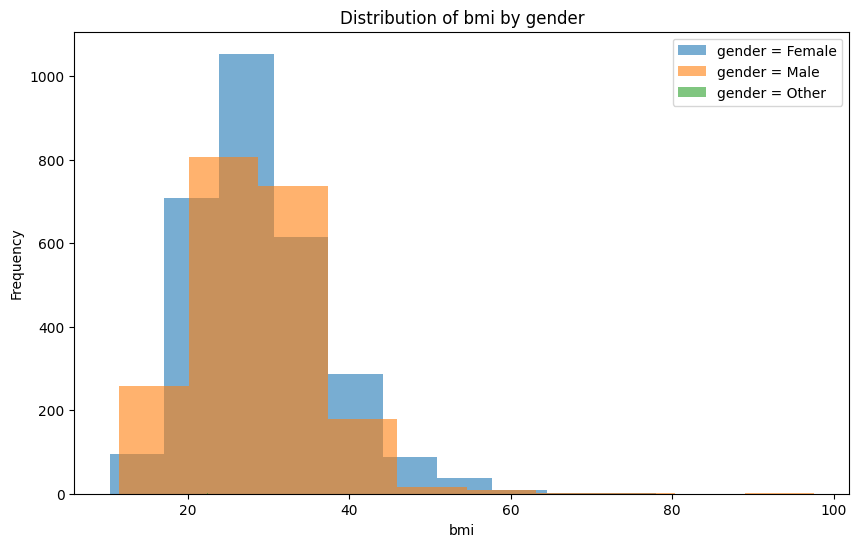


Error: 'stroke' has only '2'



In [11]:
def plot_histogram_by_category(df, continuous_col, categorical_col):
  for col in (continuous_col, categorical_col):
    if col not in df.columns:
      print(f"Error: '{col}' not found")
      return None

  n_continuous_unique = df[continuous_col].nunique()
  n_categorical_unique = df[categorical_col].nunique()

  threshold = 10
  if n_continuous_unique < threshold:
    print(f"Error: '{continuous_col}' has only '{n_continuous_unique}'")
    return None

  if n_categorical_unique >= threshold:
    print(f"Error: '{categorical_col}' has only '{n_categorical_unique}'")
    return None

  fig, ax = plt.subplots(figsize = (10,6))

  for category in sorted(df[categorical_col].dropna().unique()):
    subset = df[df[categorical_col] == category]
    values = subset[continuous_col].dropna()
    ax.hist(values, alpha = 0.6, label=f'{categorical_col} = {category}')

  ax.set_title(f'Distribution of {continuous_col} by {categorical_col}')
  ax.set_xlabel(continuous_col)
  ax.set_ylabel('Frequency')
  ax.legend()
  plt.show()



# Test Case

# age distrubution by stroke
plot_histogram_by_category(stroke_df, 'age', 'stroke')
print()

# bmi distrubution by gender
plot_histogram_by_category(stroke_df, 'bmi', 'gender')
print()

# stroke as continuous and age as categorical
plot_histogram_by_category(stroke_df, 'stroke', 'age')
print()

# Problem 9: Analyzing Group-wise Statistics with `groupby`

So far, we have looked at the data as a whole. However, the real power of data analysis comes from comparing different segments of the data. The `groupby()` method is the cornerstone of this process. It allows you to:

1. Split the data into groups based on some criteria.
2. Apply a function (like `sum()`, `mean()`, `size()`) to each group independently.
3. Combine the results into a new data structure.

In this problem, you will use `groupby()` to calculate the prevalence of stroke across different demographic groups.

### Definition of Prevalence:
For this exercise, we define stroke prevalence as the proportion of people in a specific group who have had a stroke.

\[
\text{Prevalence} = \frac{\text{Number of stroke cases in a group}}{\text{Total number of people in that group}}
\]

## Task:

Write a Python function called `calculate_stroke_prevalence`.

## Function Requirements:

### Arguments:
The function must accept two arguments:

i. `df`: The pandas DataFrame to use (`stroke_df`).

ii. `group_by_cols`: A list of strings, where each string is a column name to group the data by (e.g., `['gender']` or `['ever_married', 'work_type']`).

### Functionality:

i. Use the `.groupby()` method on the DataFrame with the columns specified in `group_by_cols`.

ii. Calculate the total size of each resulting group. (Hint: The `.size()` method is perfect for this.)

iii. Calculate the number of stroke occurrences for each group. (Hint: Since the `'stroke'` column is `1` for a stroke and `0` otherwise, the `.sum()` of this column within a group gives you the total number of strokes.)

iv. Divide the stroke counts by the group sizes to compute the prevalence for each group.

v. The result of this calculation will be a pandas Series. Convert it into a clean DataFrame with a column named `stroke_prevalence`.

vi. Finally, use `.reset_index()` to turn the group labels from the index back into columns.

vii. Return the final, tidy DataFrame.

### Edge Cases:

Be sure to handle these edge cases by printing a useful message and returning `None`.

i. Any of the columns specified by `group_by_cols` are not categorical columns. Test this similarly to how you tested it in Problem 7.

ii. Any of the columns in `group_by_cols` are not found in the provided dataframe.

---

## Test your function:

1. Call your function to find the stroke prevalence grouped by `'smoking_status'`.

2. Call your function to find the stroke prevalence grouped by `['ever_married', 'work_type']`.

3. Call your function grouped by `['age']`. (case where grouping column is not categorical).

4. Call your function grouped by `['residence_type']` (case where column is not found due to capitalization mismatch).
"""

In [12]:
def calculate_stroke_prevalance(df, group_by_cols):
  threshold = 10

  for col in group_by_cols:
    if col not in df.columns:
      print(f"Error: '{col}' not found")
      return None

    if df[col].nunique() >= threshold:
      print(f"Error: '{col}' has more than {threshold} categories")
      return None

  grouped = df.groupby(group_by_cols)
  group_sizes = grouped.size()
  stroke_counts = grouped['stroke'].sum()

  prevalence = stroke_counts / group_sizes

  result = prevalence.to_frame(name='stroke prevalence').reset_index()
  return result


# Test Cases

# By smoking_status
print(calculate_stroke_prevalance(stroke_df, ['smoking_status']))
print()

# By ever_married and work_type
print(calculate_stroke_prevalance(stroke_df, ['ever_married', 'work_type']))
print()

# By age
print(calculate_stroke_prevalance(stroke_df, ['age']))
print()

# By residence_type
print(calculate_stroke_prevalance(stroke_df, ['residence_type']))

    smoking_status  stroke prevalence
0          Unknown           0.030440
1  formerly smoked           0.079096
2     never smoked           0.047569
3           smokes           0.053232

  ever_married      work_type  stroke prevalence
0           No       Govt_job           0.051282
1           No   Never_worked           0.000000
2           No        Private           0.017052
3           No  Self-employed           0.063636
4           No       children           0.002911
5          Yes       Govt_job           0.050000
6          Yes        Private           0.064163
7          Yes  Self-employed           0.081805

Error: 'age' has more than 10 categories
None

Error: 'residence_type' not found
None



# Problem 10: Building a Preprocessing Pipeline for Analysis

Before data can be used to train a machine learning model or run a statistical analysis, it must be properly cleaned and transformed. Raw data often contains missing values, features on vastly different scales, and non-numeric categorical data that most algorithms cannot handle.

In this exercise, you will create a single, powerful function that performs several common preprocessing steps to make our stroke dataset "analysis-ready."

## Key Preprocessing Concepts:

1. **Imputation:** The process of filling in missing values (`NaN`). A simple strategy for numerical data is to replace missing values with the mean of the column.

2. **Standard Scaling:** Transforming data to have a mean of 0 and a standard deviation of 1. This is crucial for algorithms that are sensitive to the scale of input features (like SVMs or regression with regularization). The formula is:

   \[
   z = \frac{(x - mean)}{std\_dev}
   \]

3. **One-Hot Encoding:** Converting categorical variables (like `'work_type'`) into a numerical format. It creates new binary (0 or 1) columns for each category.

4. **Dropping Columns:** Removing columns that are not useful for analysis, such as unique identifiers (`'id'`).

## Task:

Write a Python function called `preprocess_for_analysis`. This function will serve as a reusable pipeline for preparing your data.

## Function Requirements:

### Arguments:

The function must accept the following arguments:

i. `df`: The input DataFrame.

ii. `cols_to_impute`: A list of column names that require mean imputation.

iii. `cols_to_scale`: A list of numerical column names to be standardized.

iv. `cols_to_encode`: A list of categorical column names to be one-hot encoded.

v. `cols_to_drop`: A list of column names to be dropped from the DataFrame.

### Functionality:

i. **Important:** Start by creating a copy of the input DataFrame to avoid modifying the original data.

ii. Perform the transformations in a logical order:

&nbsp;&nbsp;&nbsp;&nbsp;a. Drop the specified columns.

&nbsp;&nbsp;&nbsp;&nbsp;b. Impute the missing values in the specified columns using the column's mean.

&nbsp;&nbsp;&nbsp;&nbsp;c. Scale the specified numerical columns. Rename the scaled columns using the pattern `'{original_col_name}_scaled'` and drop the original unscaled column.

&nbsp;&nbsp;&nbsp;&nbsp;d. One-hot encode the specified categorical columns using `pd.get_dummies()`.

&nbsp;&nbsp;&nbsp;&nbsp;e. Make sure to drop the original categorical columns after encoding and join the new encoded columns to the DataFrame.

&nbsp;&nbsp;&nbsp;&nbsp;**Hint:** Using `drop_first=True` in `get_dummies` is good practice to avoid multicollinearity.

iii. Return the final, fully processed DataFrame.

## Test your function:

- Define lists for each set of columns to be transformed.

- Call your function with the `stroke_df` and these lists:

```python
scale_list = ['age', 'avg_glucose_level', 'bmi']
encode_list = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
drop_list = ['id', 'location_code']

In [13]:
def preprocess_for_analysis(df, impute_cols, scale_cols, encode_cols, drop_cols):

  # making a copy
  df = stroke_df.copy()

  # Dropping
  df = df.drop(columns=drop_cols, errors = 'ignore')

  # imputing
  for col in impute_cols:
    df[col] = df[col].fillna(df[col].mean())

  # Scaling
  for col in scale_cols:
    df[f'{col}_scaled'] = (df[col] - df[col].mean()) / df[col].std()
    df = df.drop(columns = [col])

  # one-hot encoding
  df = pd.get_dummies(df, columns = encode_cols, drop_first = True, dtype = int)

  return df

# Test Cases

drop_cols = ['id', 'location_code']
impute_cols = ['bmi']
scale_cols = ['age', 'avg_glucose_level', 'bmi']
encode_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

preprocessed_df = preprocess_for_analysis(stroke_df, impute_cols, scale_cols, encode_cols, drop_cols)

print(preprocessed_df.head())
print()
preprocessed_df.info()

   hypertension  heart_disease  stroke  cardiovascular_disease  age_scaled  \
0             0              1       1                       1    1.051331   
1             0              0       1                       0    0.785993   
2             0              1       1                       1    1.626231   
3             0              0       1                       0    0.255317   
4             1              0       1                       1    1.582008   

   avg_glucose_level_scaled    bmi_scaled  gender_Male  gender_Other  \
0                  2.706111  1.001136e+00            1             0   
1                  2.121351  4.615102e-16            0             0   
2                 -0.005028  4.685314e-01            1             0   
3                  1.437217  7.153482e-01            0             0   
4                  1.501038 -6.356489e-01            0             0   

   ever_married_Yes  work_type_Never_worked  work_type_Private  \
0                 1             

# Problem 11: Joins in Pandas with the merge method.

In data analysis, your data is often split across multiple tables. For instance, you might have one table with patient health data and another table that maps location codes to city and state names. To get a complete picture, you need to combine, or "join," these tables.

In pandas, the primary tool for this is the `df.merge()` method, which implements database-style joins. The most common type of join is a left join, which keeps all records from the "left" DataFrame and adds matching information from the "right" DataFrame.

## Task:

Your goal is to enrich the `stroke_df` with the city and state information from `location_codes_df`, loaded from the location_codes.csv file.

1. Perform a left join using `stroke_df` as the left dataframe, `locations_codes_df` as the right dataframe, and `location_code` as the join on column.

2. Store the result in a new DataFrame called `merged_df`.

3. Show the head of `merged_df`. Look closely at the last few columns to confirm that `city` and `state` have been successfully added.
"""

In [14]:
# loading location
location_df = pd.read_csv('/content/drive/MyDrive/AIHC5020/stroke/location_codes.csv')

print('location_code' in stroke_df.columns)
print('location_code' in location_df.columns)

merged_df = stroke_df.merge(location_df, on = 'location_code', how = 'left')

print(merged_df.head())

True
True
      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   
2        Private          Rural             105.92  32.5     never smoked   
3        Private          Urban             171.23  34.4           smokes   
4  Self-employed          Rural             174.12  24.0     never smoked   

   stroke  location_code  cardiovascular_disease          city state  
0       1            143                       

# Problem 12: Introduction to SQL with DuckDB

While pandas is excellent for data manipulation in Python, SQL (Structured Query Language) is the universal language for interacting with relational databases. In data analysis, you will almost certainly use SQL.

Fortunately, a powerful library called DuckDB allows us to run SQL queries directly on our pandas DataFrames without needing to set up a separate database. This is a perfect way to learn and practice SQL syntax. To use it, add `import duckdb` to your list of imports.

## The Basic SQL Query Structure:

A SQL query for joining and filtering data looks like this:

```sql
SELECT columns_you_want
FROM left_table_name AS alias1
LEFT JOIN right_table_name AS alias2 ON alias1.key_column = alias2.key_column
WHERE some_condition_is_true;

In [15]:
# SQL Query: I have used pandasql and sqldf before. It is interesting to note, the syntax is alomst exactly same for both packages.
# Would definetly love to read up more on the differences of the two

sql_query = """
SELECT *
FROM stroke_df AS sdf
LEFT JOIN location_df as ldf
ON sdf.location_code = ldf.location_code
WHERE ldf.state = 'NY'
"""

sql_df = duckdb.query(sql_query).to_df()

print(sql_df.head())
print()
print(sql_df['state'].unique())

      id  gender   age  hypertension  heart_disease ever_married  \
0  37937  Female  75.0             0              1           No   
1  17004  Female  70.0             0              0          Yes   
2  56841    Male  58.0             0              1          Yes   
3  20426  Female  78.0             1              0           No   
4  66767  Female  67.0             0              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi smoking_status  \
0  Self-employed          Urban             109.78   NaN        Unknown   
1        Private          Urban             221.58  47.5   never smoked   
2        Private          Rural             240.59  31.4         smokes   
3        Private          Urban             203.87  45.7   never smoked   
4       Govt_job          Rural              94.61  28.4         smokes   

   stroke  location_code  cardiovascular_disease  location_code_1      city  \
0       1            181                       1             

# References
- https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset/code: several notebooks used such as EDA and One Hot Encoding
- https://www.geeksforgeeks.org/machine-learning/difference-between-loc-and-iloc-in-pandas-dataframe/: syntax differences in .iloc() v/s .loc()
- https://duckdb.org/docs/current/sql/introduction; used Gen AI for comparison between duckdb and sqldf
- Used Gen AI to develop markup text for problem question (did that manually last time) and insert comments in code
- Uploaded Problems 1-6 from VS Code into colab